In [1]:
%load_ext autoreload
%autoreload 2

import plotly.express as px
import torch
import torch.optim as optim
import utils
from models.custom_net import Net
from models.resnet_fine_tuning import get_resnet_model
from torch import nn
from torch.utils.tensorboard import SummaryWriter
from torchmetrics import MetricCollection
from torchmetrics.classification import (
    MulticlassAccuracy,
    MulticlassConfusionMatrix,
    MulticlassF1Score,
    MulticlassPrecision,
    MulticlassRecall,
)
from torchvision.transforms import v2
from train import Trainer

# Обучение

## Custom_net

In [2]:
custom_net_train_transform = v2.Compose(
    [
        v2.ToImage(),
        v2.Resize(size=140),
        v2.RandomHorizontalFlip(p=0.5),
        v2.RandomCrop(size=(130, 130)),
        v2.ColorJitter(brightness=0.1, contrast=0.1),
        v2.ToDtype(torch.float32, scale=True),
    ]
)
custom_net_test_transform = v2.Compose(
    [
        v2.ToImage(),
        v2.Resize(size=140),
        v2.CenterCrop(size=(130, 130)),
        v2.ToDtype(torch.float32, scale=True),
    ]
)

data = utils.get_datasets_and_loaders(
    train_transform=custom_net_train_transform,
    test_transform=custom_net_test_transform,
)

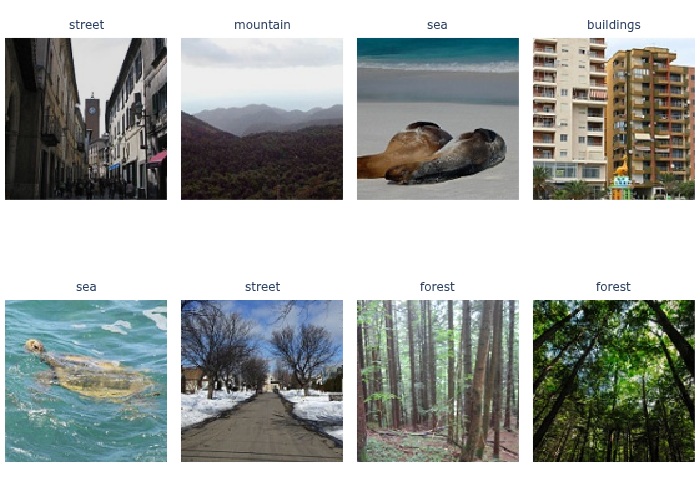

In [3]:
image, label = next(iter(data.train_loader))
image = image[0:8]
image = image.permute(0, 2, 3, 1)
# Wrap at 4 images per row
fig = px.imshow(image, facet_col=0, facet_col_wrap=4, facet_col_spacing=0.0)

for i in range(image.shape[0]):
    # Note: when wrapping, Plotly re-indexes annotations differently,
    # so we target them by their current text "facet_col=i"
    fig.update_annotations(
        {"text": data.classes[label[i]], "yanchor": "top", "yshift": -10},
        selector={"text": f"facet_col={i}"},
    )

fig.update_xaxes(showticklabels=False)
fig.update_yaxes(showticklabels=False)
fig.update_layout(margin=dict(t=5, l=5, r=5, b=5))
fig.show(renderer="png")

In [4]:
num_epochs = 30

custom_net = Net()

new_params = []
old_params = []
for name, param in custom_net.named_parameters():
    if not any(sub in name for sub in ["final_linear", "conv1x1_2"]):
        old_params.append(param)
    else:
        new_params.append(param)

loaders = {"train_loader": data.train_loader, "valid_loader": data.valid_loader}

optimizer = optim.Adam(
    [{"params": old_params, "lr": 1e-6}, {"params": new_params, "lr": 1e-4}],
    weight_decay=1e-4,
)
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer, max_lr=[1e-5, 1e-3], total_steps=len(data.train_loader) * num_epochs
)
opt = utils.OptimizationSuite(
    criterion=nn.CrossEntropyLoss(), optimizer=optimizer, scheduler=scheduler
)

log = utils.LoggingSuite(
    metrics=MetricCollection(
        {
            "Accuracy": MulticlassAccuracy(num_classes=6, average="micro"),
            "Precision": MulticlassPrecision(num_classes=6, average="macro"),
            "Recall": MulticlassRecall(num_classes=6, average="macro"),
            "F1": MulticlassF1Score(num_classes=6, average="macro"),
        }
    ),
    conf_matrix=MulticlassConfusionMatrix(num_classes=6),
    writer=SummaryWriter(),
)

conf = utils.TrainerConfig(checkpoint_path="checkpoints/custom_net/")

trainer_custom_net = Trainer(custom_net, data, opt, log, conf)
start_epoch = trainer_custom_net.load_checkpoint(
    path="checkpoints/custom_net/best_model_checkpoint.pth", verbose=False
)

In [ ]:
trainer_custom_net.fit(num_epochs=num_epochs, start_epoch=start_epoch)

## Resnet

In [5]:
image_net_mean = [0.485, 0.456, 0.406]
image_net_std = [0.229, 0.224, 0.225]

resnet_train_transform = v2.Compose(
    [
        v2.ToImage(),
        v2.Resize(size=(224, 224)),
        v2.RandomHorizontalFlip(p=0.5),
        v2.ColorJitter(brightness=0.1, contrast=0.1),
        v2.ToDtype(torch.float32, scale=True),
        v2.Normalize(mean=image_net_mean, std=image_net_std),
    ]
)
resnet_test_transform = v2.Compose(
    [
        v2.ToImage(),
        v2.Resize(size=(224, 224)),
        v2.ToDtype(torch.float32, scale=True),
        v2.Normalize(mean=image_net_mean, std=image_net_std),
    ]
)

data = utils.get_datasets_and_loaders(
    train_transform=resnet_train_transform,
    test_transform=resnet_test_transform,
)

In [6]:
num_epochs = 10

resnet = get_resnet_model(classes=data.classes)

unfreeze_layers = ["layer4", "fc"]
learnable_params = []
for name, param in resnet.named_parameters():
    if any([layer_name in name for layer_name in unfreeze_layers]):
        learnable_params.append(param)
    else:
        param.requires_grad = False

loaders = {"train_loader": data.train_loader, "valid_loader": data.valid_loader}

optimizer = optim.Adam(
    [
        {"params": resnet.layer4.parameters(), "lr": 1e-5},
        {"params": resnet.fc.parameters(), "lr": 1e-3},
    ]
)
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer, max_lr=[1e-4, 1e-2], total_steps=len(data.train_loader) * num_epochs
)
opt = utils.OptimizationSuite(
    criterion=nn.CrossEntropyLoss(), optimizer=optimizer, scheduler=scheduler
)

log = utils.LoggingSuite(
    metrics=MetricCollection(
        {
            "Accuracy": MulticlassAccuracy(num_classes=6, average="micro"),
            "Precision": MulticlassPrecision(num_classes=6, average="macro"),
            "Recall": MulticlassRecall(num_classes=6, average="macro"),
            "F1": MulticlassF1Score(num_classes=6, average="macro"),
        }
    ),
    conf_matrix=MulticlassConfusionMatrix(num_classes=6),
    writer=SummaryWriter(),
)

conf = utils.TrainerConfig(checkpoint_path="checkpoints/resnet/")

trainer_resnet = Trainer(resnet, data, opt, log, conf)
start_epoch = trainer_resnet.load_checkpoint(
    path="checkpoints/resnet/best_model_checkpoint.pth", verbose=False
)

In [ ]:
trainer_resnet.fit(num_epochs=num_epochs, start_epoch=0)

# Тестирование

In [7]:
custom_net_test = trainer_custom_net.test()
resnet_test = trainer_resnet.test()

Testing:   0%|          | 0/24 [00:00<?, ?it/s]

Testing:   0%|          | 0/24 [00:00<?, ?it/s]

In [8]:
utils.display_side_by_side(
    [custom_net_test[0], custom_net_test[1]],
    ["Confusion matrix", "Metrics"],
    "Custom net",
)
print(
    "Custom net\n",
    f"Total params = {sum(p.numel() for p in custom_net.parameters()):,}\n"
    f"Trainable params = {sum(p.numel() for p in custom_net.parameters() if p.requires_grad):,}\n",
)
utils.display_side_by_side(
    [resnet_test[0], resnet_test[1]], ["Confusion matrix", "Metrics"], "Resnet"
)
print(
    "Resnet\n",
    f"Total params = {sum(p.numel() for p in resnet.parameters()):,}\n"
    f"Trainable params = {sum(p.numel() for p in resnet.parameters() if p.requires_grad):,}\n",
)

Custom net
 Total params = 375,622
Trainable params = 375,622



Resnet
 Total params = 11,179,590
Trainable params = 8,396,806



# Результаты

### Сравнение моделей

- Resnet18 показала лучшие результаты достигнув точности **93.8%** на тестовой выборке. Использование transfer learning позволило обучиться намного быстрее, опираясь на уже выученные моделью фичи. Были разморожены последний слой `fc` и `layer4`, на котором использовался маленький `lr`
- Custom net имеет почти в 30 раз меньше параметров, но все равно показывает достойные результаты с точностью **88%** на тестовой выборке

### Анализ ошибок

Из матрицы ошибок выдны паттерны ошибок, которые допускают обе модели:

- Больше всего ошибок допущено между классами `glacier`(ледник) и `mountain`(гора), что объясняется визуальным сходством (большое количество снега, рельеф)
- Так же модели сильно путают `street`(улица) и `buildings`(здания), что тоже выглядит правдоподобно (на улицах много зданий)
- Меньше всего ошибок допущено в классе `forest`, так как он уникален по сравнению с другими (отличительный цвет и текстура)

### Архитектура

- Custom net основывалась на принципе DenseNet, где признаки изученные на предыдущих слоях конкатенируются с последующими, в отличии от Resnet, где они суммируются (`x + f(x)`). Это позволяет использовать сырые признаки, предотвращая потерю информации и уменьшая размер модели
- Для Resnet использовалась стандартная Resnet18 обученная на ImageNet